In [1]:
%pip install -e /home/darshan/A6/PCSAFT_cDFT/thermoift
import time
notebook_start = time.perf_counter()

import  os
import  json
import  pandas as pd
import  numpy as np
import  matplotlib.pyplot as plt
import  thermoift.PLOT_SETTINGS as ps
from    thermoift import MLPostprocessing, plot_correlation_heatmap, print_model_metrics
from    thermoift.rng_utils import get_rng
from    sklearn.model_selection import train_test_split, cross_val_score

Obtaining file:///home/darshan/A6/PCSAFT_cDFT/thermoift
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for thermoift (pyproject.toml) ... done
  Created wheel for thermoift: filename=thermoift-0.2.0-0.editable-py3-none-any.whl size=1730 sha256=540d5b981e422fde526ad4fdea695ead28d03eb6d67a65b5d3346b7002ece216
  Stored in directory: /tmp/pip-ephem-wheel-cache-9u5h2lnp/wheels/fd/2f/c4/54a2ee5cd16a9bf5b183bbe5c28d1b3ba4926fb0261a13e1e4
Successfully built thermoift
  Attempting uninstall: thermoift
    Found existing installation: thermoift 0.2.0
    Uninstalling thermoift-0.2.0:
      Successfully uninstalled thermoift-0.2.0
Note: you may need to restart the kernel to use updated packages.


In [ ]:
PLOT_FOLDER     = "TabPFN_OUTPUTS"
SLURM_RUN_FULL  = False
TEST_ROWS       = 100
SEED            = 50005

In [3]:
try:
    import tabpfn
    from tabpfn import TabPFNRegressor
    from tabpfn.constants import ModelVersion

    if SLURM_RUN_FULL:
        os.environ["TABPFN_ALLOW_CPU_LARGE_DATASET"] = "1"

    print(f"TabPFN version: {tabpfn.__version__}")
    print("Selected model version:", ModelVersion.V2)

except ImportError as exc:
    raise ImportError("tabpfn is not installed in this Python environment.") from exc

TabPFN version: 6.4.1
Selected model version: ModelVersion.V2


In [15]:
df = pd.read_csv("../interfacial_results_dataset_A1.csv")
print(f"Number of rows: {len(df)}")

if not SLURM_RUN_FULL:
    df = df.iloc[:TEST_ROWS].copy()
    print(f"Test mode: using first {TEST_ROWS} rows only")
else:
    print("Full mode: using all rows")

print(f"Total samples: {len(df)}")
print(f"\ngamma statistics:")
print(df["gamma"].describe())

Number of rows: 19171
Test mode: using first 100 rows only
Total samples: 100

gamma statistics:
count    100.000000
mean      12.476355
std        2.930751
min        7.227385
25%       10.127040
50%       12.377921
75%       14.480421
max       19.876084
Name: gamma, dtype: float64


In [5]:
target     = "gamma"
rng        = get_rng(seed=SEED)

z_columns  = [col for col in df.columns if col.startswith("z_")]
Z_non_zero = [col for col in z_columns if (df[col] != 0).any()]
features   = ["temperature", "pressure"] + Z_non_zero

print(f"Selected features: {features}")

X = df[features]
y = df[target]

# 70/15/15 split: first 70/30, then split 30 into 15/15
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, random_state=SEED)
X_test, X_val, y_test, y_val = train_test_split(X_temp, y_temp, test_size=0.50, random_state=SEED)

print(f"\nTraining samples:   {X_train.shape[0]}")
print(f"Testing samples:    {X_test.shape[0]}")
print(f"Validation samples: {X_val.shape[0]}")

Selected features: ['temperature', 'pressure', 'z_carbon dioxide', 'z_hydrogen', 'z_oxygen', 'z_carbon monoxide']

Training samples:   70
Testing samples:    15
Validation samples: 15


Feature correlations with gamma:
pressure            -0.70541
temperature         -0.89175
z_carbon dioxide         NaN
z_hydrogen               NaN
z_oxygen                 NaN
z_carbon monoxide        NaN
Name: gamma, dtype: float64


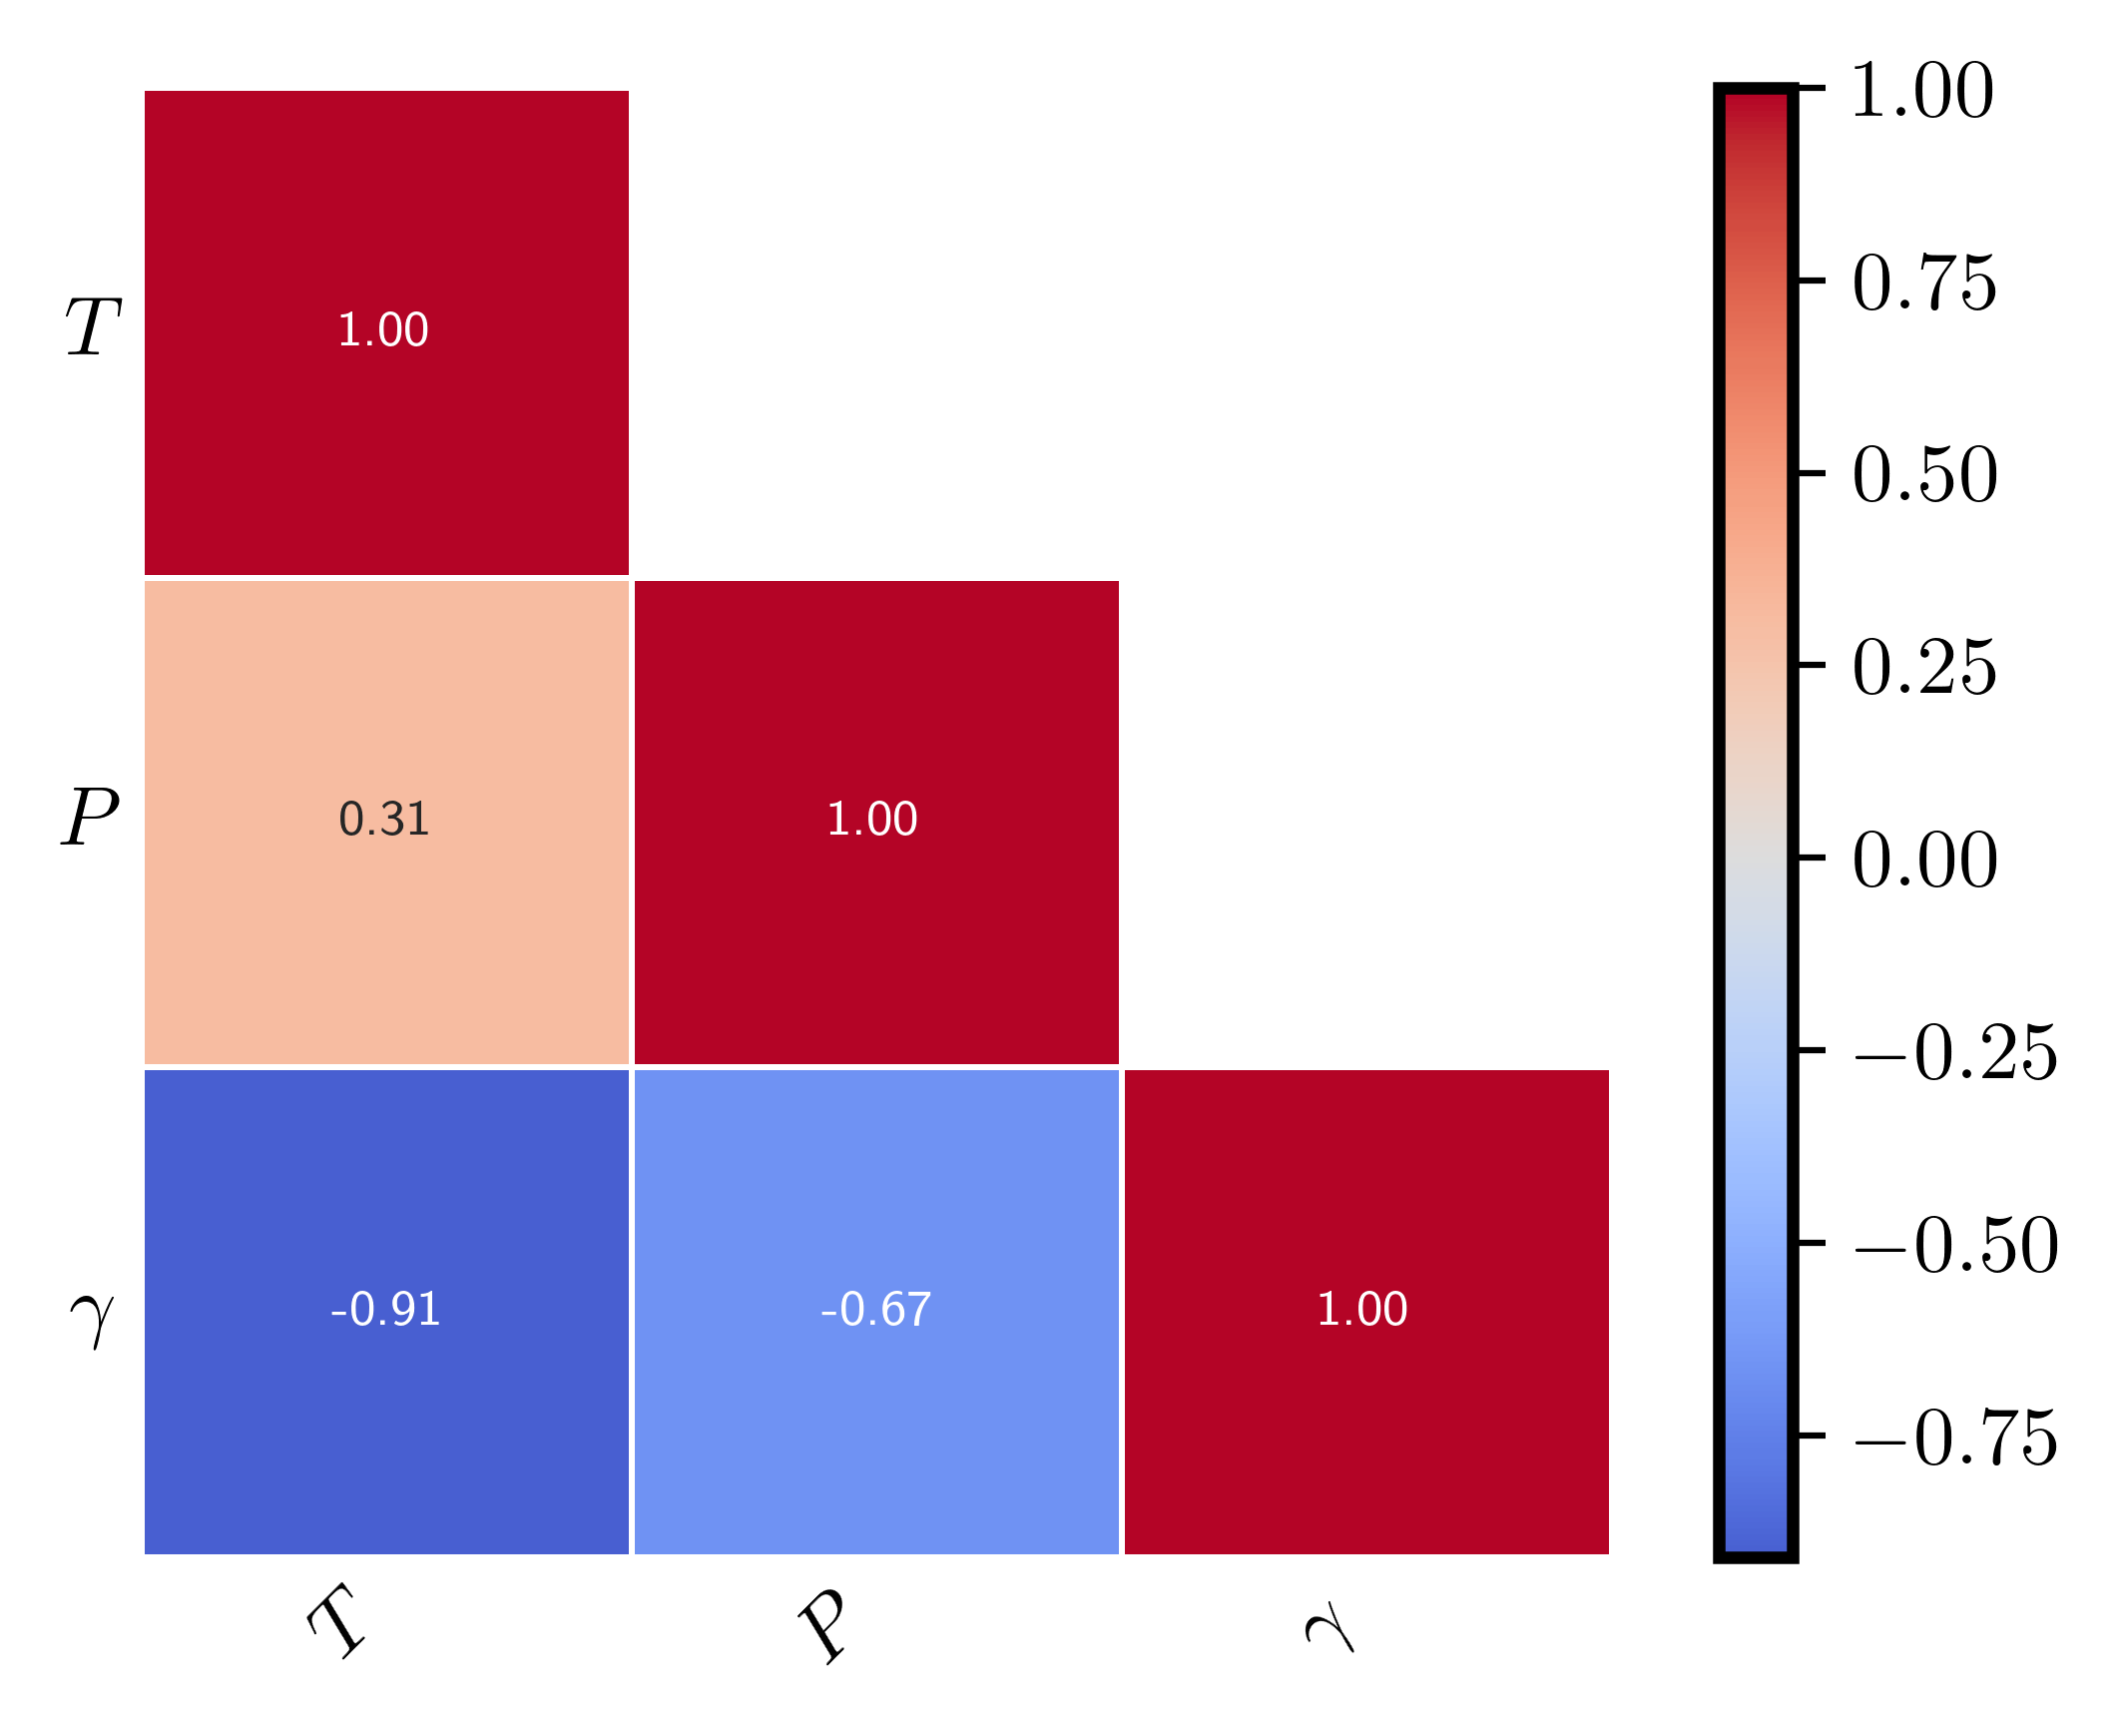

(<Figure size 2400x1800 with 2 Axes>, <Axes: >)

In [6]:
plot_correlation_heatmap(df, features, target, save_path="TabPFN_gamma_correlation", folder=PLOT_FOLDER)

In [7]:
# Train TabPFN model
tabpfn_model = TabPFNRegressor(random_state=SEED, ignore_pretraining_limits=True, fit_mode="fit_preprocessors")
tabpfn_model.fit(X_train, y_train)

# Predictions
y_train_pred = tabpfn_model.predict(X_train)
y_test_pred  = tabpfn_model.predict(X_test)
y_val_pred   = tabpfn_model.predict(X_val)

# Metrics
metrics = print_model_metrics(y_train, y_train_pred, y_test, y_test_pred, target, unit="mN/m", y_val=y_val, y_val_pred=y_val_pred)

Model Performance for gamma

Training Set:
  R²:   0.999997
  RMSE: 0.004816 mN/m
  MAE:  0.003561 mN/m

Test Set:
  R²:   0.999964
  RMSE: 0.018910 mN/m
  MAE:  0.008097 mN/m

Validation Set:
  R²:   0.999992
  RMSE: 0.006872 mN/m
  MAE:  0.004220 mN/m


In [8]:
# 5-fold cross-validation
cv_scores = cross_val_score(tabpfn_model, X, y, cv=5, scoring='r2')

print(f"Cross-Validation R² Scores: {cv_scores}")
print(f"Mean CV R²: {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})")

Cross-Validation R² Scores: [0.95129    0.99978689 0.99989532 0.99974067 0.87722448]
Mean CV R²: 0.9656 (+/- 0.0960)


In [9]:
# Initialize MLPostprocessing
post = MLPostprocessing(
    y_true=y_test,
    y_pred=y_test_pred,
    target="gamma",
    feature_names=features,
    datasets={
        "train": (y_train, y_train_pred),
        "test":  (y_test,  y_test_pred),
        "val":   (y_val,   y_val_pred),
    },
)

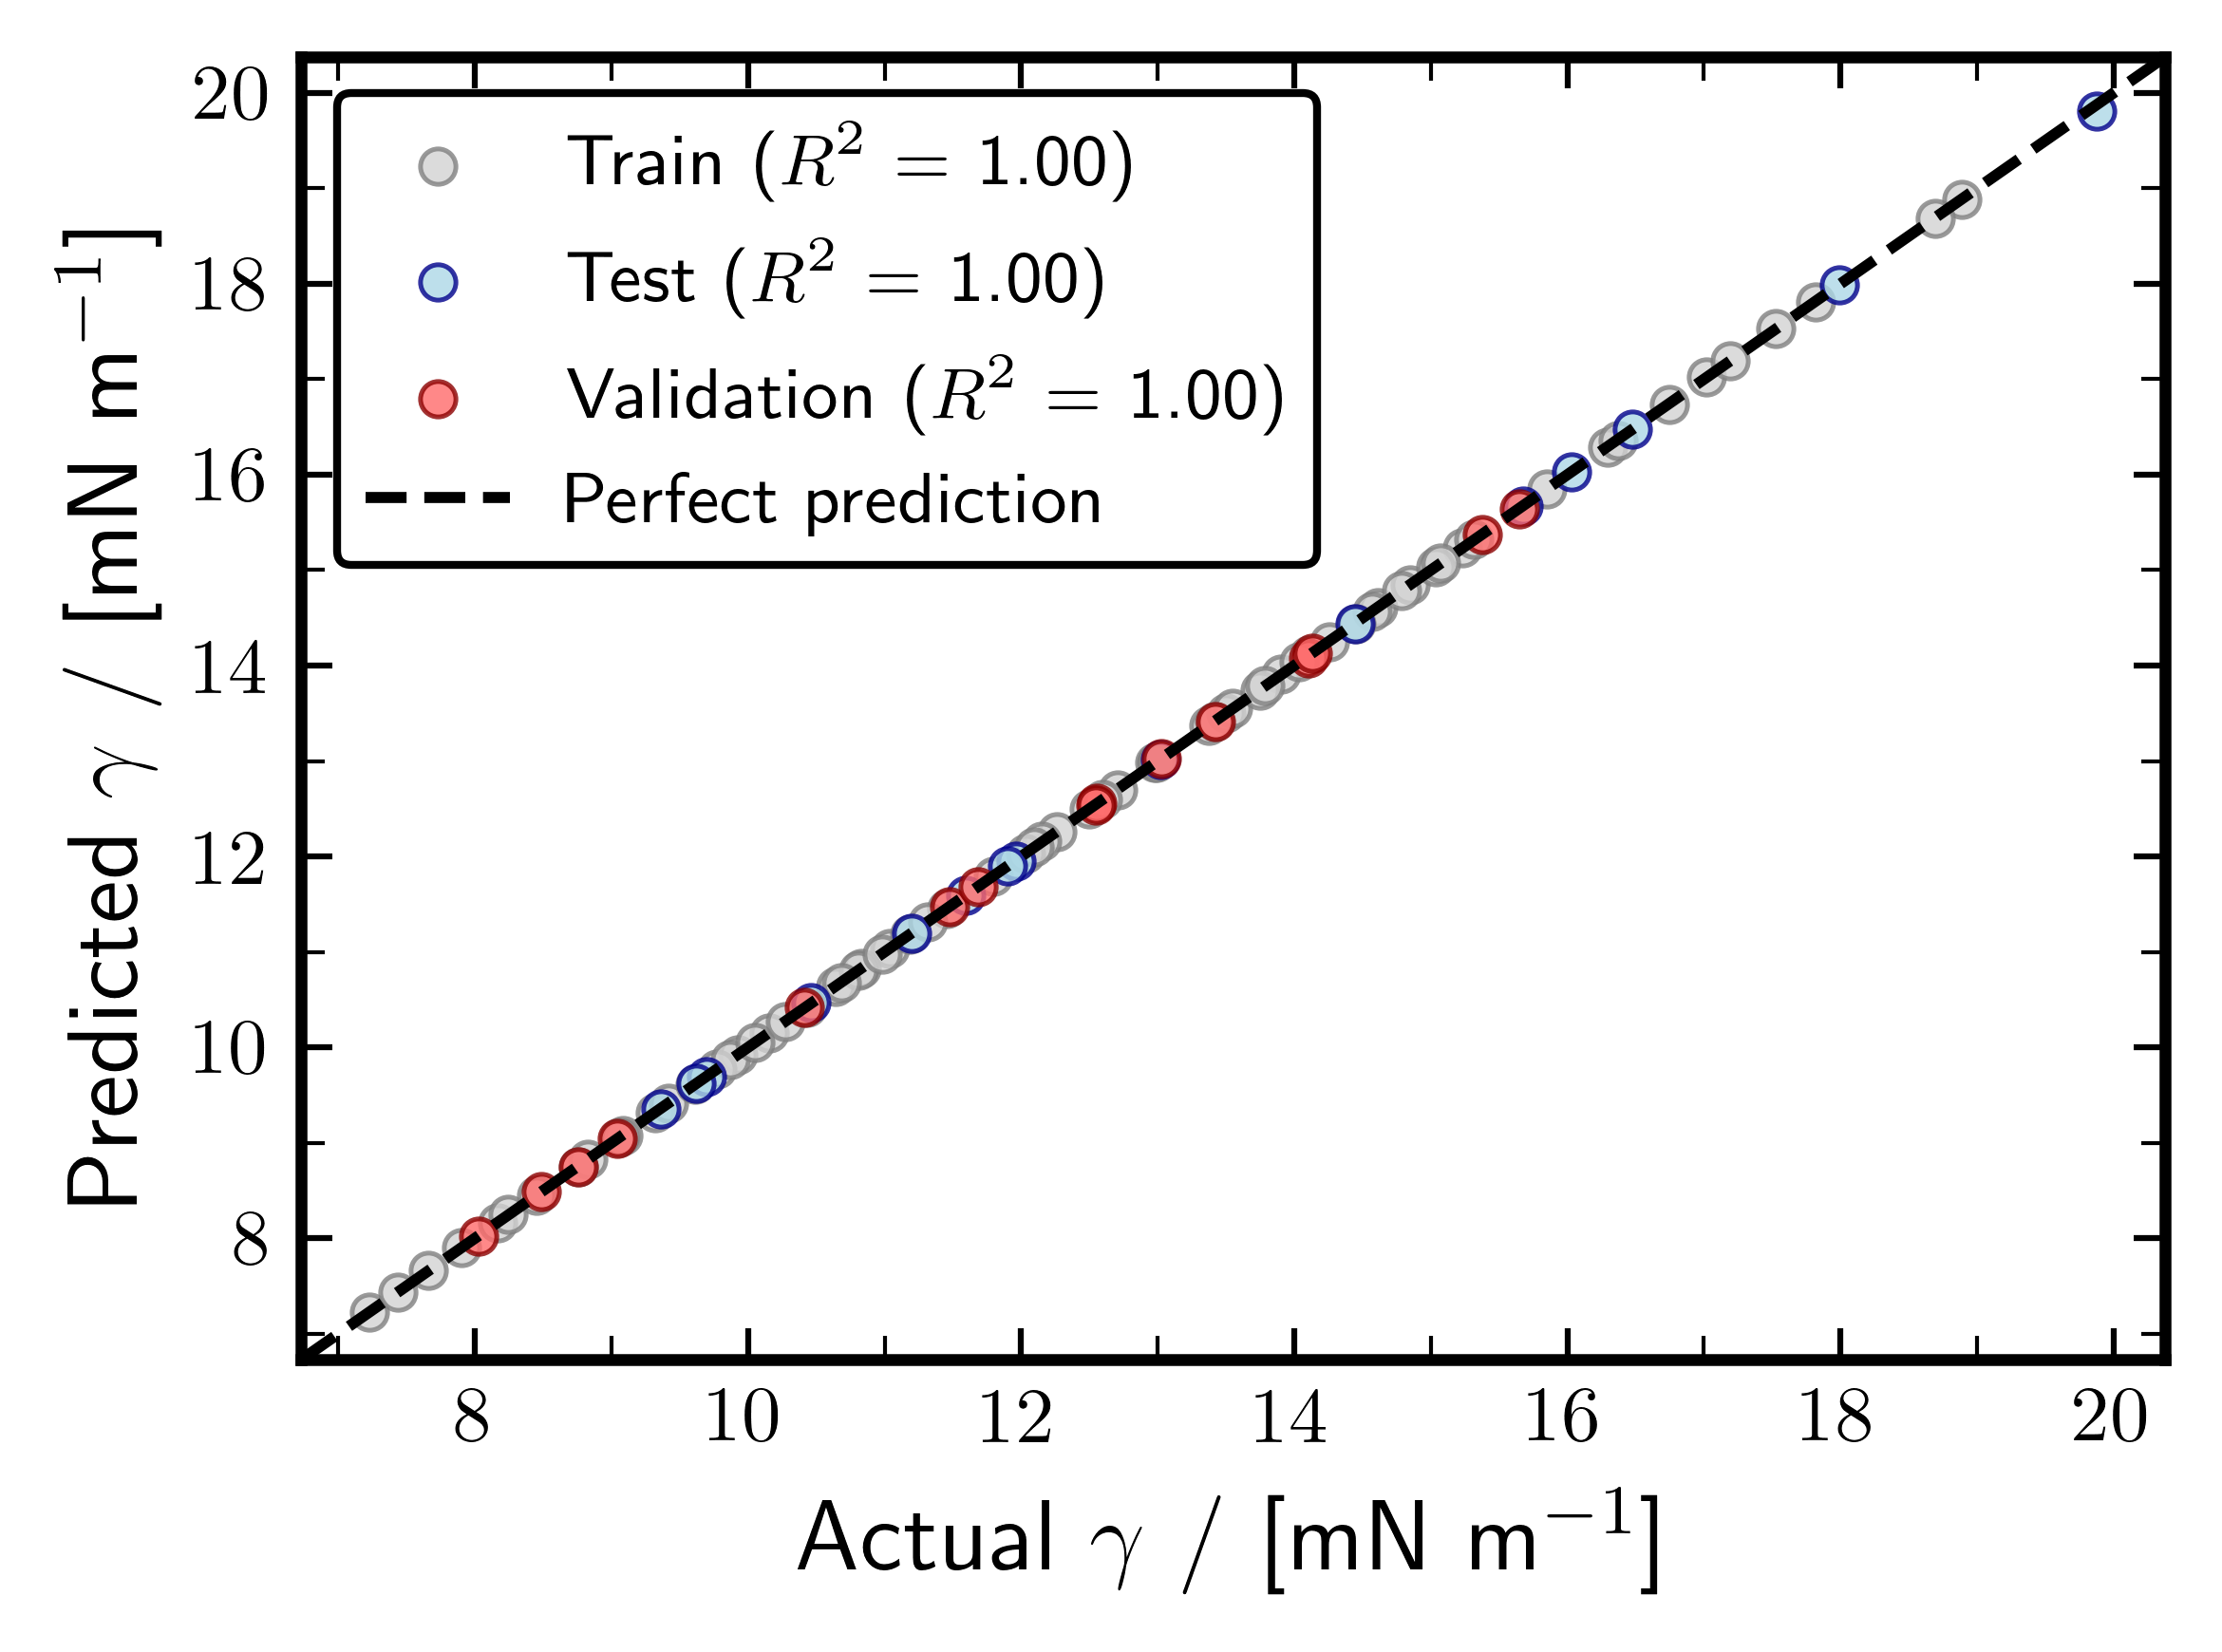

(<Figure size 2400x1800 with 1 Axes>,
 <Axes: xlabel='Actual $\\gamma$ / [mN m$^{-1}$]', ylabel='Predicted $\\gamma$ / [mN m$^{-1}$]'>)

In [10]:
# Parity plot
post.plot_parity(model_name="TabPFN", save_path="TabPFN_gamma_parity_plot", folder=PLOT_FOLDER)

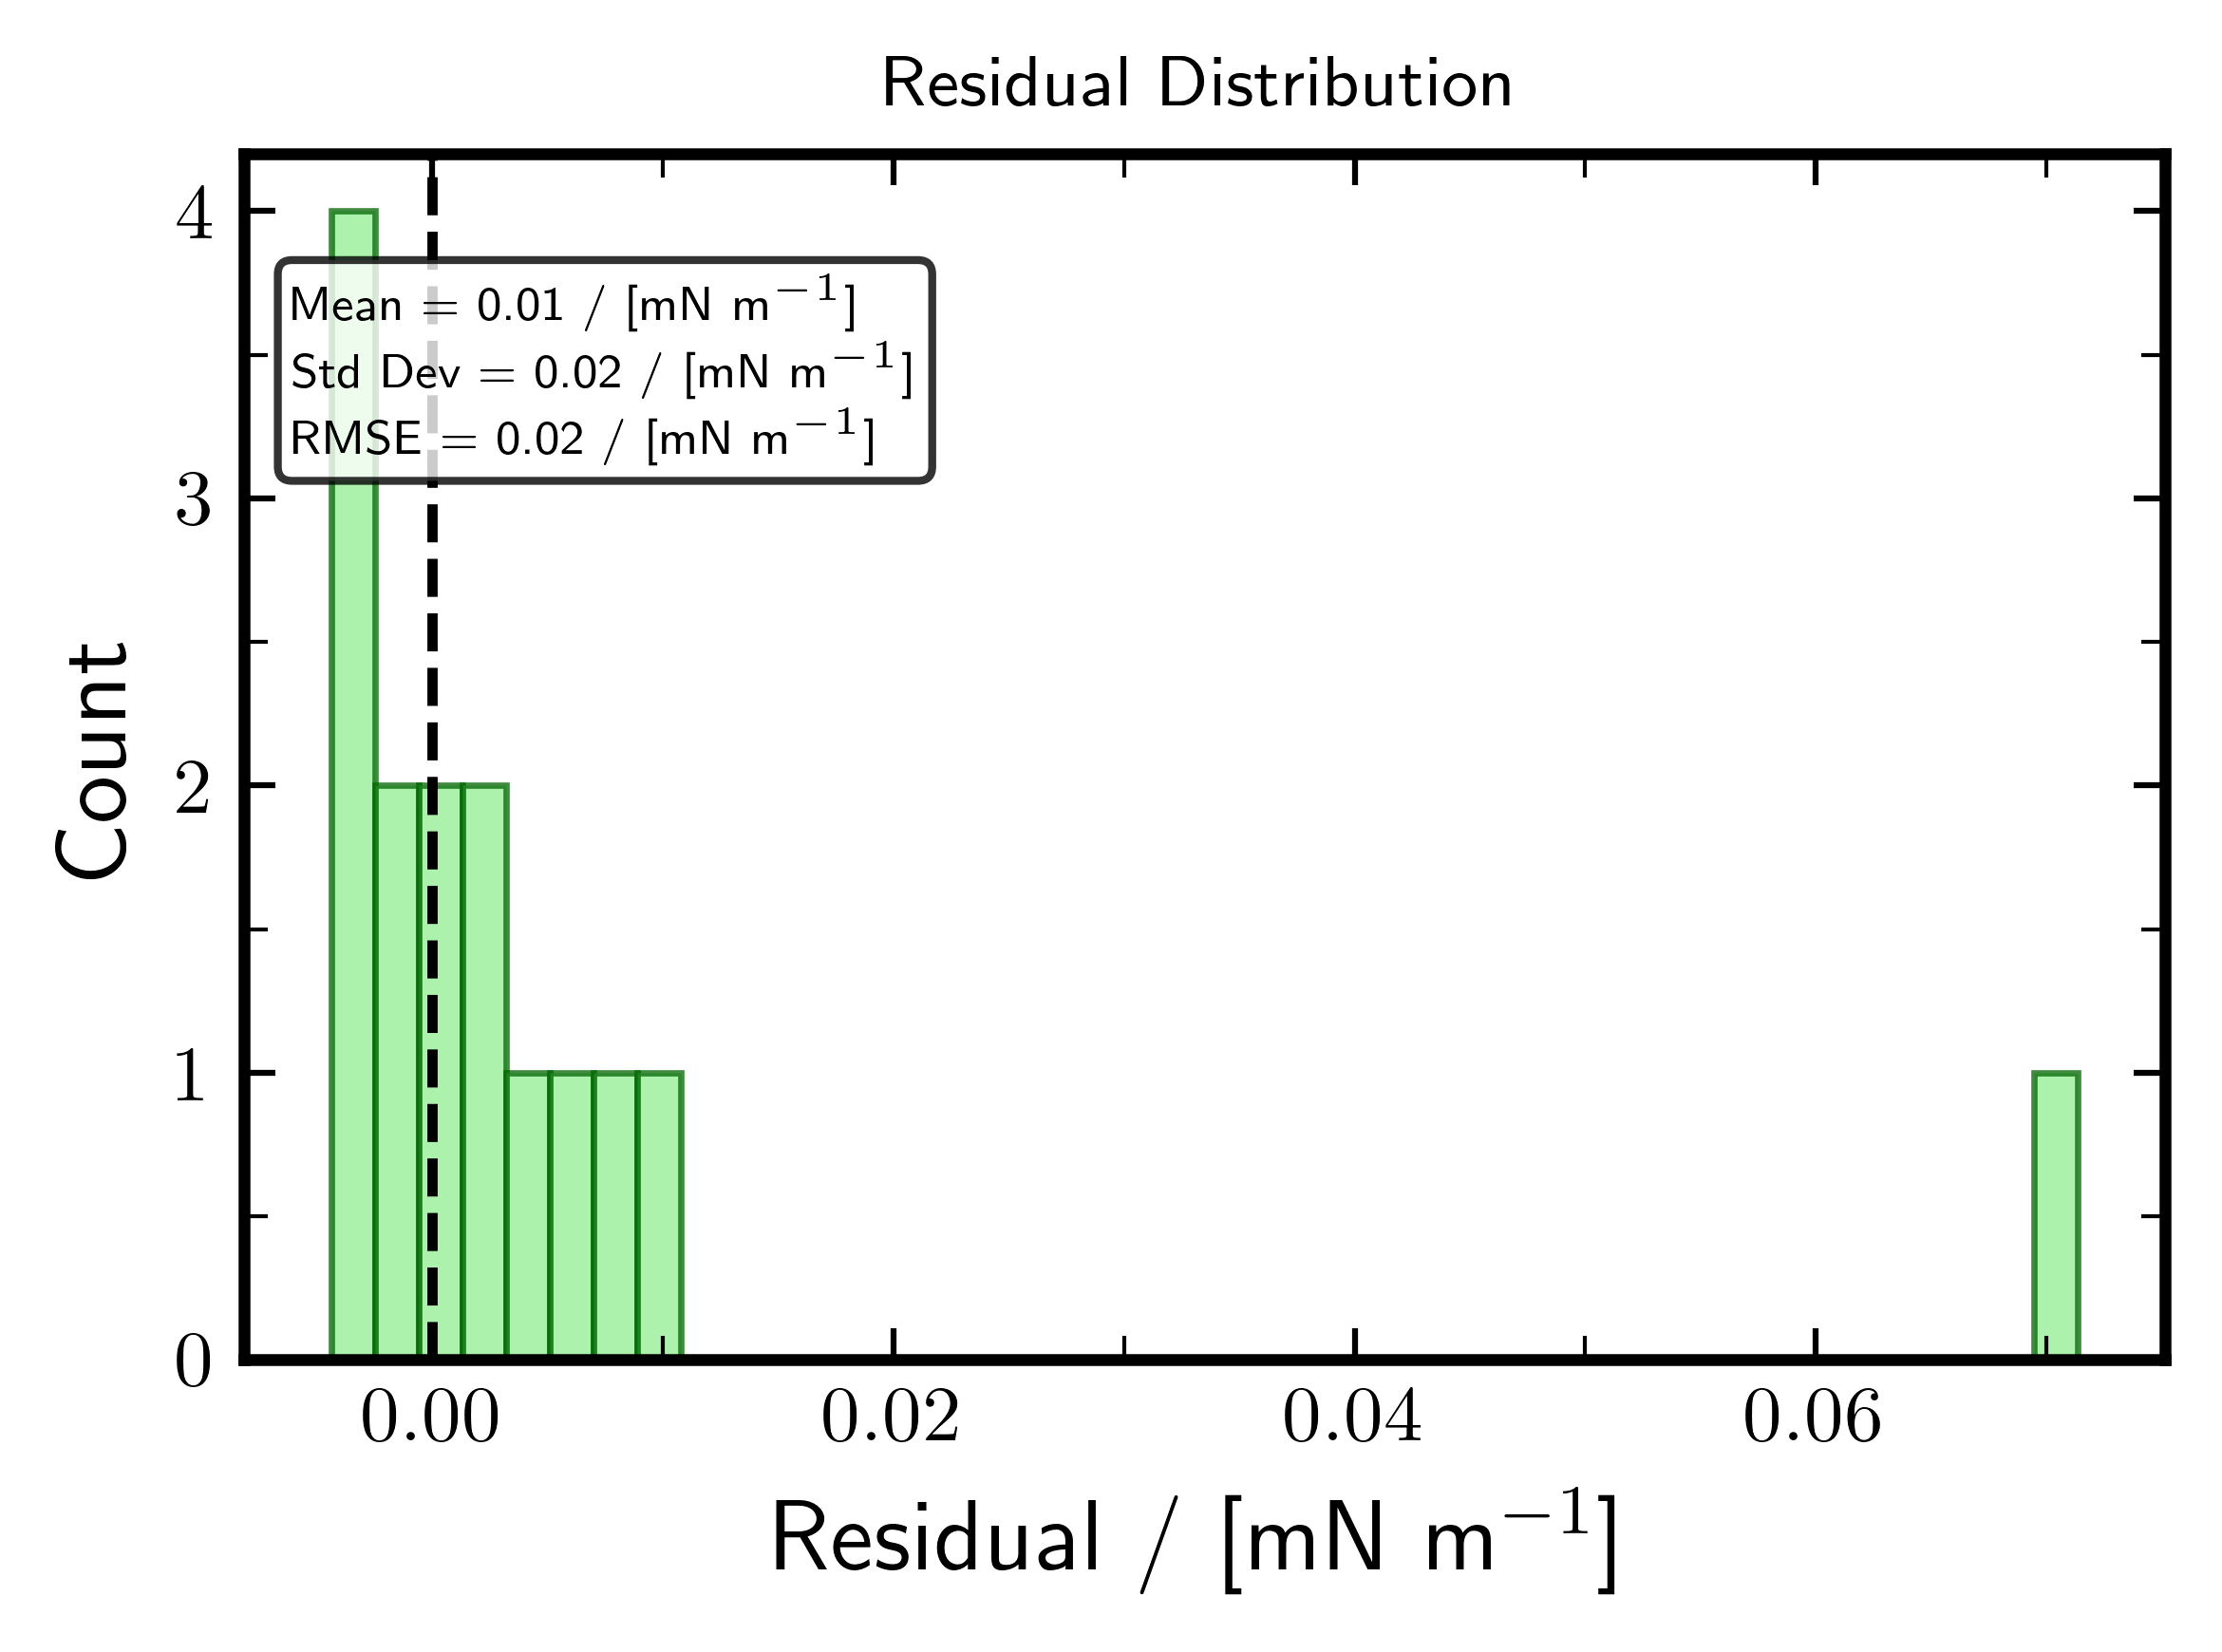

(<Figure size 2400x1800 with 1 Axes>,
 <Axes: title={'center': 'Residual Distribution'}, xlabel='Residual / [mN m$^{-1}$]', ylabel='Count'>)

In [11]:
# Residual distribution
post.plot_residual_distribution(save_path="TabPFN_gamma_residual_distribution", folder=PLOT_FOLDER)

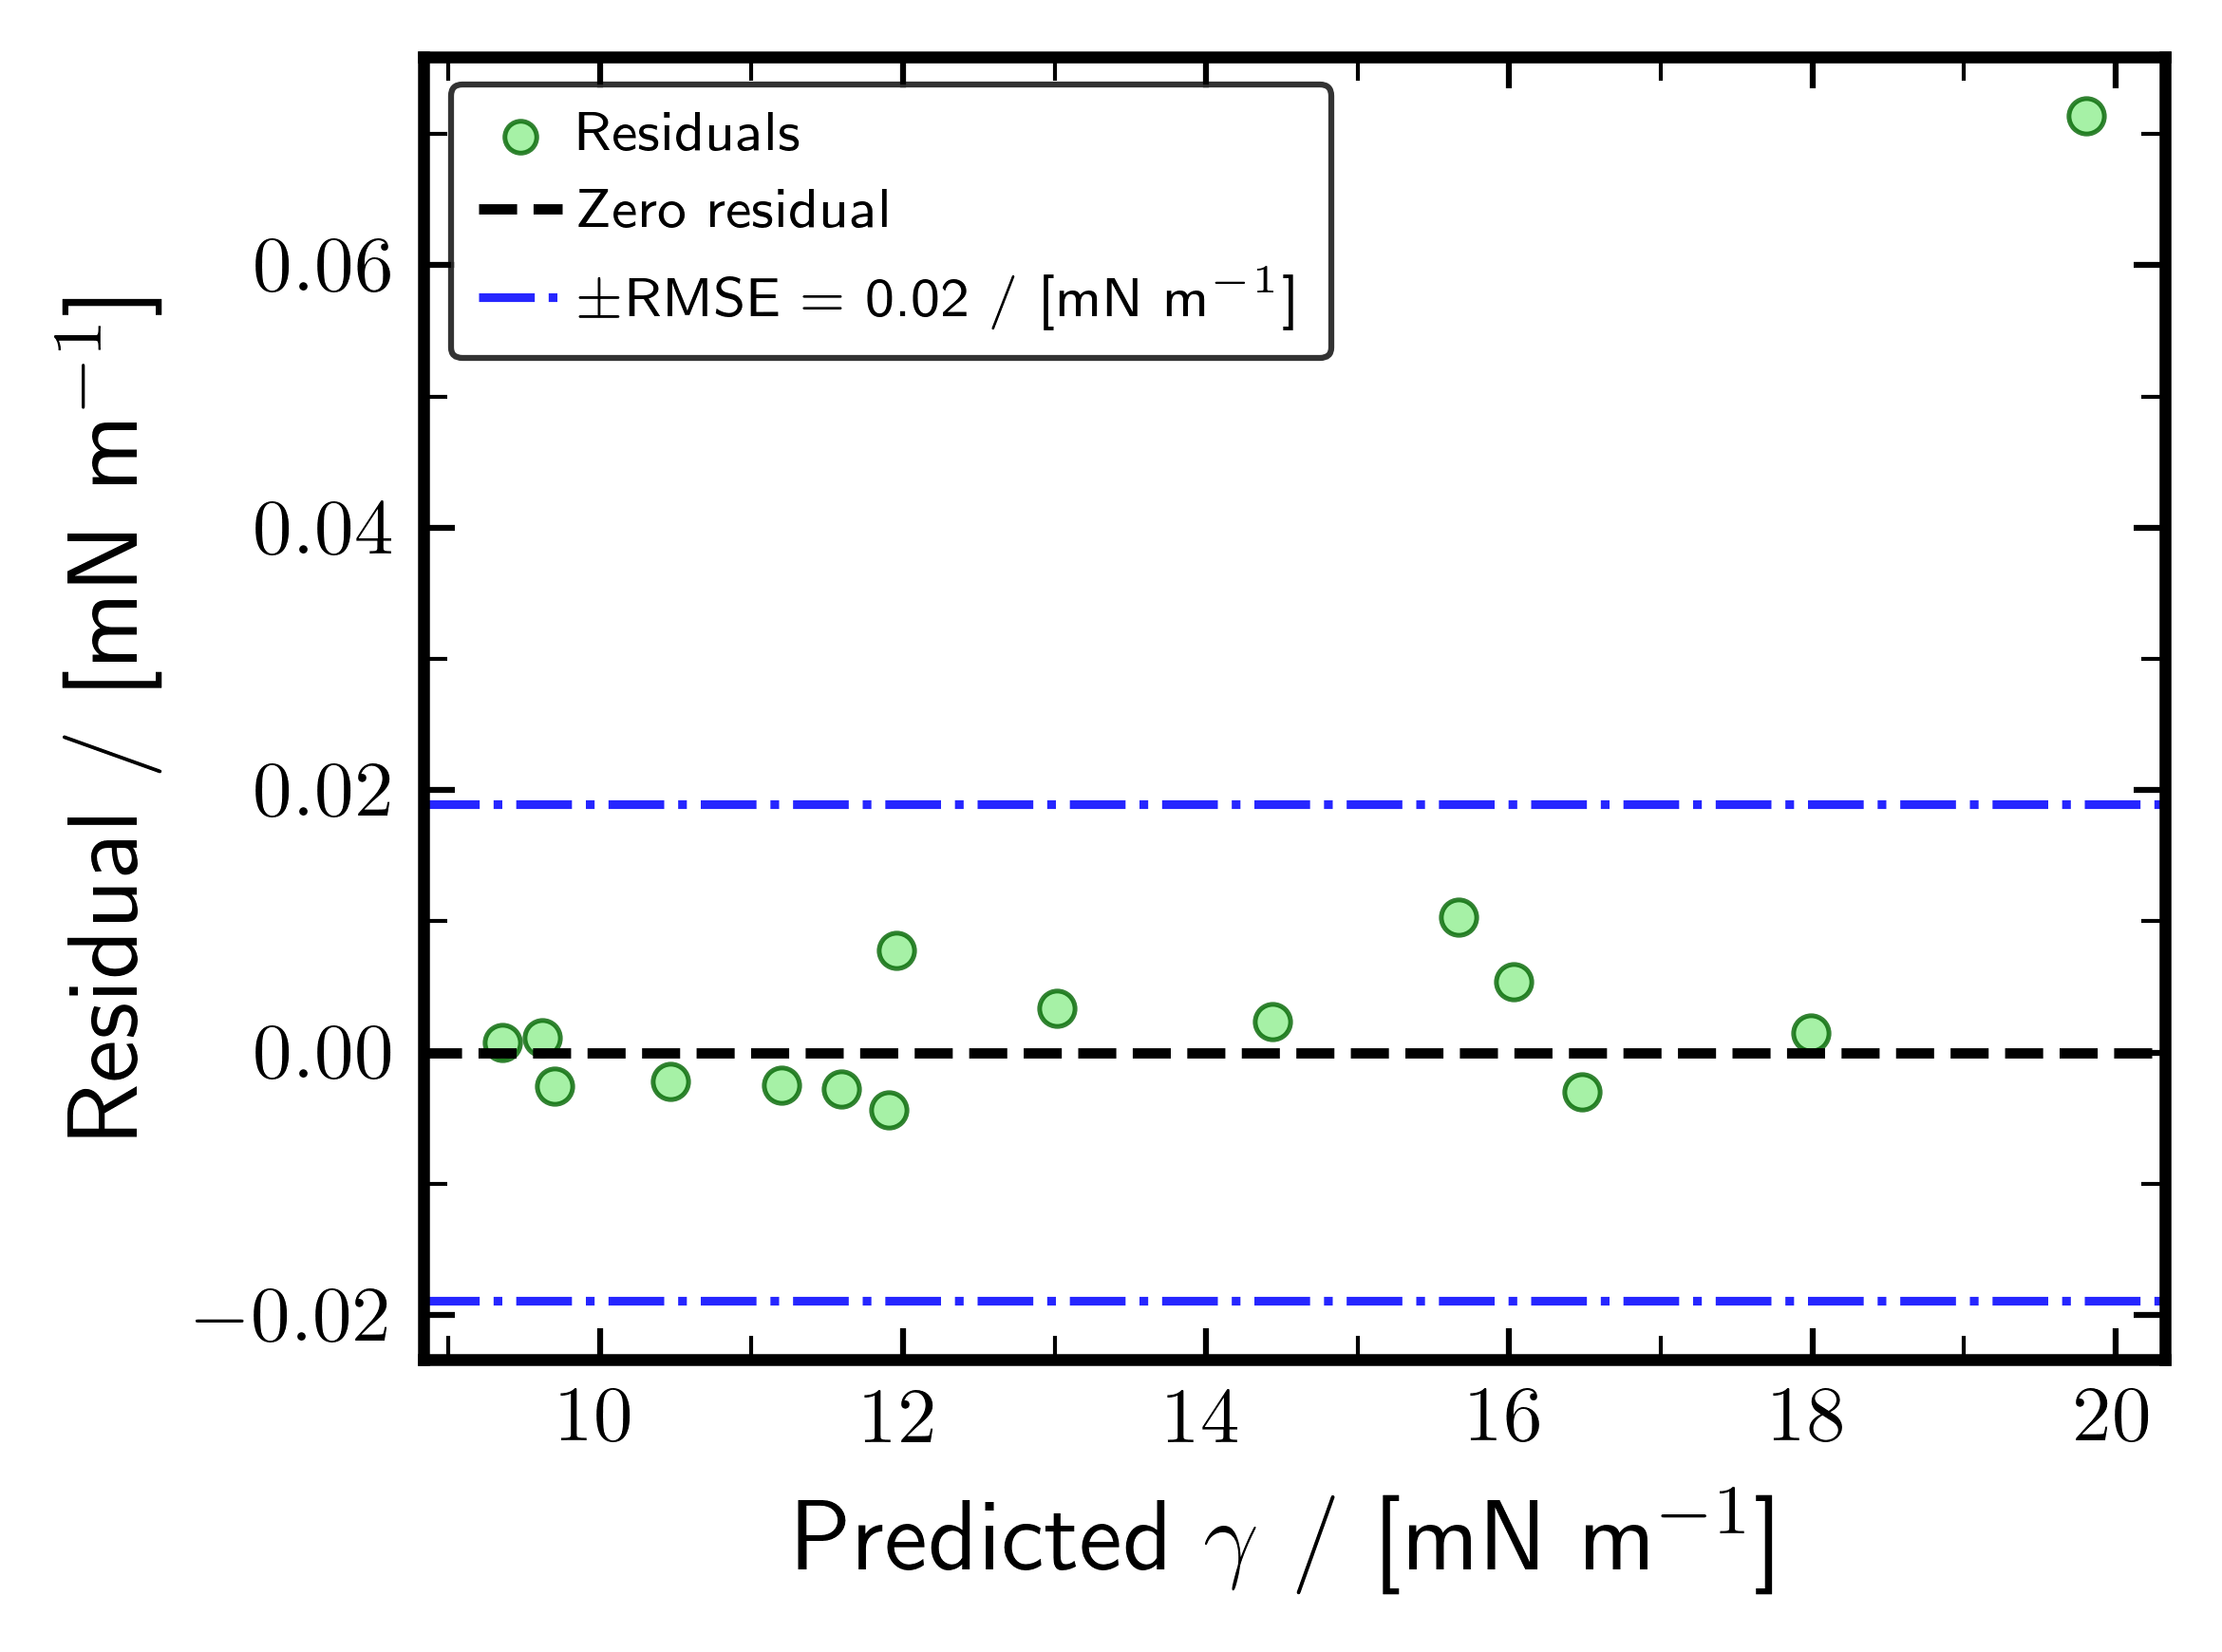

(<Figure size 2400x1800 with 1 Axes>,
 <Axes: xlabel='Predicted $\\gamma$ / [mN m$^{-1}$]', ylabel='Residual / [mN m$^{-1}$]'>)

In [12]:
# Residuals vs Predicted
post.plot_residual_vs_predicted(save_path="TabPFN_gamma_residual_vs_predicted", folder=PLOT_FOLDER)

In [13]:
post.print_summary()

# Collect all metrics
metrics["cv_r2_scores"]  = cv_scores.tolist()
metrics["cv_r2_mean"]    = float(cv_scores.mean())
metrics["cv_r2_std"]     = float(cv_scores.std())
metrics["model"]         = "TabPFN"
metrics["features"]      = features
metrics["target"]        = target
metrics["seed"]          = SEED

# Save metrics to JSON
os.makedirs(PLOT_FOLDER, exist_ok=True)
metrics_path = os.path.join(PLOT_FOLDER, f"TabPFN_{target}_metrics.json")
with open(metrics_path, "w") as f:
    json.dump(metrics, f, indent=2, default=str)

print(f"\nMetrics saved to: {metrics_path}")

MODEL PERFORMANCE SUMMARY - GAMMA
Samples:        15
R² Score:       0.999964
RMSE:           0.018910
MAE:            0.008097
Mean Residual:  0.005785
Std Residual:   0.018004

Metrics saved to: TabPFN_OUTPUTS/TabPFN_gamma_metrics.json


In [14]:
notebook_end = time.perf_counter()
elapsed_minutes = (notebook_end - notebook_start) / 60
print(f"Total notebook runtime: {elapsed_minutes:.2f} minutes")

Total notebook runtime: 2.74 minutes
